In [42]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [43]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from nltk.cluster.kmeans import KMeansClusterer
from nltk.cluster.util import euclidean_distance
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [44]:
# --------------------------- Explore dataset ------------------------------
# copied from ucimlrepo web
from ucimlrepo import fetch_ucirepo

# fetch dataset
support2 = fetch_ucirepo(id=880)

# data (as pandas dataframes)
# X = support2.data.features
# y = support2.data.targets

# # metadata
# print(support2.metadata)

# # variable information
# print(support2.variables)

In [45]:
# --------------------------- Explore features ------------------------------
# print(support2.data.features)

In [46]:
# # --------------------------- Explore targets ------------------------------
# print(support2.data.targets)

In [47]:
# --------------------------- Examine NaNs ------------------------------
X = support2.data.features

cols = X.columns
total_rows = X.shape[0]

Nan_info = {}
Nan_info_readable = {}

for c in cols:
  total_nans = X[c].isna().sum()
  percent_nans = int(total_nans / total_rows * 100)
  Nan_info[c] = percent_nans
  Nan_info_readable[c] = f'{percent_nans:.0f}%'

print(Nan_info_readable)

{'age': '0%', 'sex': '0%', 'dzgroup': '0%', 'dzclass': '0%', 'num.co': '0%', 'edu': '17%', 'income': '32%', 'scoma': '0%', 'charges': '1%', 'totcst': '9%', 'totmcst': '38%', 'avtisst': '0%', 'race': '0%', 'sps': '0%', 'aps': '0%', 'surv2m': '0%', 'surv6m': '0%', 'hday': '0%', 'diabetes': '0%', 'dementia': '0%', 'ca': '0%', 'prg2m': '18%', 'prg6m': '17%', 'dnr': '0%', 'dnrday': '0%', 'meanbp': '0%', 'wblc': '2%', 'hrt': '0%', 'resp': '0%', 'temp': '0%', 'pafi': '25%', 'alb': '37%', 'bili': '28%', 'crea': '0%', 'sod': '0%', 'ph': '25%', 'glucose': '49%', 'bun': '47%', 'urine': '53%', 'adlp': '61%', 'adls': '31%', 'adlsc': '0%'}


In [48]:
# --------------------------- Quantify NaNs ------------------------------
below_10p = []
below_25p = []
below_50p = []
above_50p = []

no_nans = []

for key, value in Nan_info.items():

    if value <= 0:
        no_nans.append((key, value))

    else:
        if value < 10:
            below_10p.append((key, value))

        if value < 25:
            below_25p.append((key, value))

        if value < 50:
            below_50p.append((key, value))

        else:
            above_50p.append((key, value))


print(f'Features with no nans: {no_nans}')
print(f'Features with <10% nans: {below_10p}')
print(f'Features with <25% nans: {below_25p}')
print(f'Features with <50% nans: {below_50p}')
print(f'Features with >50% nans: {above_50p}')

Features with no nans: [('age', 0), ('sex', 0), ('dzgroup', 0), ('dzclass', 0), ('num.co', 0), ('scoma', 0), ('avtisst', 0), ('race', 0), ('sps', 0), ('aps', 0), ('surv2m', 0), ('surv6m', 0), ('hday', 0), ('diabetes', 0), ('dementia', 0), ('ca', 0), ('dnr', 0), ('dnrday', 0), ('meanbp', 0), ('hrt', 0), ('resp', 0), ('temp', 0), ('crea', 0), ('sod', 0), ('adlsc', 0)]
Features with <10% nans: [('charges', 1), ('totcst', 9), ('wblc', 2)]
Features with <25% nans: [('edu', 17), ('charges', 1), ('totcst', 9), ('prg2m', 18), ('prg6m', 17), ('wblc', 2)]
Features with <50% nans: [('edu', 17), ('income', 32), ('charges', 1), ('totcst', 9), ('totmcst', 38), ('prg2m', 18), ('prg6m', 17), ('wblc', 2), ('pafi', 25), ('alb', 37), ('bili', 28), ('ph', 25), ('glucose', 49), ('bun', 47), ('adls', 31)]
Features with >50% nans: [('urine', 53), ('adlp', 61)]


In [49]:
# ---------------------------- drop samples containing any number of NaNs -----------------------------------
# filter out nan to build basic structure for model initialization
XY = support2.data.original
initial_rows = XY.shape[0]

XY_no_nans = XY.copy().dropna()

rows_no_nans = XY_no_nans.shape[0]

print(f'Initial num samples: {initial_rows}\nSamples w/o nans: {rows_no_nans}')

Initial num samples: 9105
Samples w/o nans: 306


In [50]:
# ---------------------------- Examine classes -----------------------------------
Y = support2.data.targets
set(Y['sfdm2'])


{'<2 mo. follow-up',
 'Coma or Intub',
 'SIP>=30',
 'adl>=4 (>=5 if sur)',
 nan,
 'no(M2 and SIP pres)'}

In [51]:
# ------------------------------- Prepare data -------------------------------------------
# separate features and targets
X_no_nans = XY_no_nans.copy().drop('sfdm2', axis=1)
Y_no_nans = XY_no_nans['sfdm2']

# --------------------- Encode classes -------------------------
# using LabelEncoder
le = LabelEncoder()
Y_encoded = le.fit_transform(Y_no_nans)
Y_encoded = pd.DataFrame(Y_encoded, columns=['sfdm2'])

# combine X and Y, put in order of class for accuracy calculation
XY_encoded = pd.concat([X_no_nans, Y_encoded], axis=1)
XY_sorted = XY_encoded.sort_values(by='sfdm2')

# split
X_train, X_test, y_train, y_test = train_test_split(X_no_nans, Y_encoded, test_size=0.2, train_size=0.8, random_state=1)

scaler = StandardScaler()

X_train_cont = X_train.select_dtypes(include=['number'])
X_test_cont = X_test.select_dtypes(include=['number'])

X_train_scaled = scaler.fit_transform(X_train_cont)
X_test_scaled = scaler.transform(X_test_cont)

In [52]:
# check how target was encoded
for i, label in enumerate(le.classes_):
    print(i, label)

0 <2 mo. follow-up
1 SIP>=30
2 adl>=4 (>=5 if sur)
3 no(M2 and SIP pres)


## Unsupervised Models

--------- True Labels ---------
[0 0 3 3 2 3 0 1 0 1 3 3 3 1 1 3 1 3 0 3 3 3 2 1 3 3 3 3 1 3 3 0 2 3 1 2 1
 3 3 3 2 1 3 1 1 3 3 3 3 3 0 3 3 3 3 3 3 3 3 2 0 0 3 3 3 1 3 3 3 0 3 0 3 3
 3 3 3 3 3 3 0 2 1 3 0 0 3 3 3 3 3 3 3 0 3 3 3 3 0 0 0 1 3 0 2 3 3 0 3 3 3
 0 3 3 3 0 3 2 3 3 2 0 3 2 1 2 3 0 1 3 2 0 3 3 3 3 2 0 3 1 0 1 3 1 3 3 3 3
 0 3 3 3 3 3 3 3 3 0 3 3 0 3 3 3 0 0 3 0 3 2 2 3 1 3 3 3 1 3 3 2 0 1 3 0 3
 3 1 1 2 0 3 3 3 0 2 3 3 3 3 3 3 3 3 3 3 2 3 3 0 0 3 0 1 1 0 3 1 3 3 1 1 3
 0 3 0 0 3 3 0 3 1 3 3 3 3 3 0 3 3 1 3 3 1 2]
--------- Pred Labels ---------
[2 1 3 3 3 3 0 2 0 2 1 1 1 1 1 3 3 1 0 0 3 0 2 0 1 1 1 2 0 1 2 2 1 3 3 0 0
 1 1 1 1 3 3 3 3 3 3 3 2 1 1 3 3 3 3 1 1 3 3 3 0 0 1 1 3 0 0 1 3 0 1 1 1 1
 3 3 1 3 1 1 2 3 3 1 0 0 3 1 3 1 0 1 3 0 1 3 2 3 1 0 0 1 1 0 0 3 1 1 3 1 3
 0 0 3 3 2 1 3 3 3 0 1 3 0 3 1 3 0 3 0 2 1 1 0 1 1 0 2 1 0 0 3 3 3 1 1 1 1
 0 3 3 1 3 3 1 1 1 1 3 3 2 1 1 3 1 1 1 1 3 0 1 1 2 3 3 3 0 2 3 0 0 1 3 0 3
 1 1 2 1 0 3 0 1 1 0 3 3 0 1 3 1 1 3 1 1 1 3 0 0 1 3 1 3 0 1 3 2 

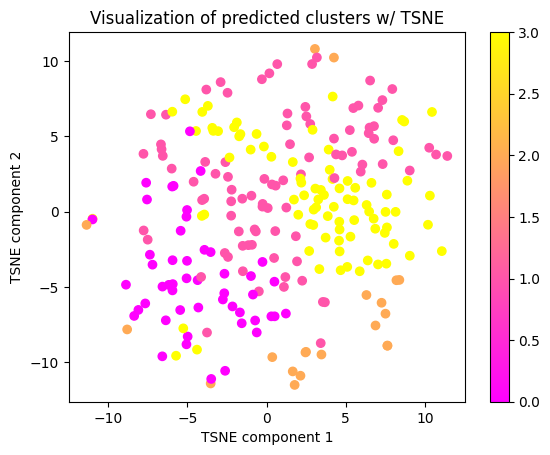

In [53]:
# ------------------------------- Unsupervised models -------------------------------------
# GaussianMixture
k = 4

my_model   = GaussianMixture(n_components = k, random_state = 0).fit(X_train_scaled)

# extract centers and pred labels
Center     = my_model.means_
PredLabels = my_model.predict(X_train_scaled)

# print pred vs true labels
print('--------- True Labels ---------')
print(y_train['sfdm2'].values)
print('--------- Pred Labels ---------')
print(PredLabels)

T = TSNE(learning_rate='auto', init='random', perplexity=30)
X_TSNE = T.fit_transform(X_train_scaled)

plt.figure()
plt.scatter(X_TSNE[:, 0], X_TSNE[:, 1], c=PredLabels, cmap='spring')
plt.xlabel('TSNE component 1')
plt.ylabel('TSNE component 2')
plt.title('Visualization of predicted clusters w/ TSNE')
plt.colorbar()
plt.show()

In [54]:
X_train_cont

,id,age,death,hospdead,slos,d.time,num.co,edu,scoma,charges,...,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc
3105,3106,67.79700,1,1,10,10,3,12.0,0.0,99187.0,...,0.699951,2.000000,137.0,7.089844,123.0,25.0,1320.0,0.0,0.0,0.0
5252,5253,69.77100,1,0,9,37,1,13.0,0.0,13072.0,...,3.899902,0.599976,138.0,7.339844,305.0,25.0,239.0,0.0,0.0,0.0
8922,8923,68.64099,0,0,7,559,3,13.0,0.0,6748.0,...,1.099854,0.899902,136.0,7.449219,74.0,24.0,1500.0,2.0,1.0,1.0
7047,7048,69.91895,0,0,9,859,2,5.0,0.0,12092.0,...,1.199951,0.899902,137.0,7.479492,203.0,17.0,2800.0,0.0,0.0,0.0
5506,5507,59.04700,0,0,17,490,2,8.0,0.0,35298.0,...,1.899902,1.500000,141.0,7.529297,93.0,27.0,1975.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7301,7302,59.00299,0,0,25,668,1,9.0,0.0,37381.0,...,1.099854,1.000000,139.0,7.419922,141.0,22.0,1645.0,4.0,4.0,4.0
7654,7655,46.53497,0,0,13,422,1,12.0,0.0,17345.0,...,0.699951,0.799927,137.0,7.439453,298.0,11.0,1594.0,6.0,5.0,5.0
3200,3201,76.67096,0,0,13,386,3,16.0,0.0,30798.0,...,0.399963,2.899902,130.0,7.379883,234.0,64.0,1190.0,0.0,0.0,0.0
7523,7524,76.41595,0,0,6,513,2,12.0,0.0,17222.0,...,0.899902,1.399902,131.0,7.409180,137.0,33.0,2581.0,1.0,0.0,0.0


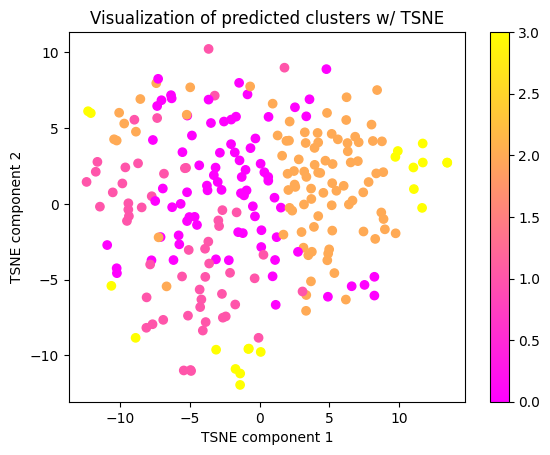

In [55]:
# K-means

X_array_kmeans = X_train_scaled

k = 4
rep = 25
dist = euclidean_distance

my_model = KMeansClusterer(k, distance = dist, repeats = 25, avoid_empty_clusters = True)
Labels = my_model.cluster(X_array_kmeans, assign_clusters = True)

Labels = np.array(Labels)

T = TSNE(learning_rate='auto', init='random', perplexity=30)
X_TSNE = T.fit_transform(X_array_kmeans)

plt.figure()
plt.scatter(X_TSNE[:, 0], X_TSNE[:, 1], c=Labels, cmap='spring')
plt.xlabel('TSNE component 1')
plt.ylabel('TSNE component 2')
plt.title('Visualization of predicted clusters w/ TSNE')
plt.colorbar()
plt.show()

## Supervised Models

/Users/anika/miniconda3/envs/MSSE_python/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


accuracy: 61.29%


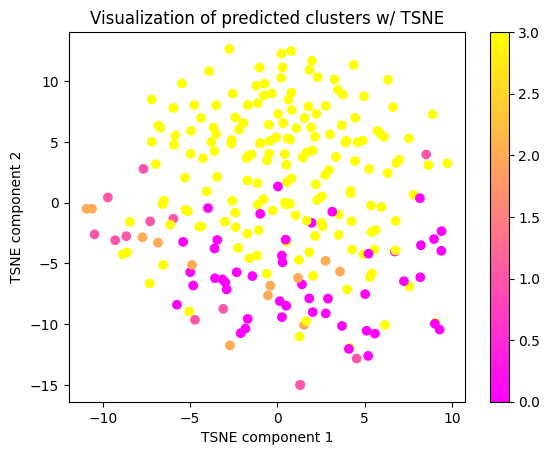

In [57]:
# -------------------------- Multinomial Logistic Regression -----------------------------
my_model = LogisticRegression()

my_model.fit(X_train_scaled, y_train)

y_train_pred = my_model.predict(X_train_scaled)
y_test_pred = my_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred) * 100
print(f"accuracy: {accuracy:.2f}%")

Labels = np.array(y_train_pred)

T = TSNE(learning_rate='auto', init='random', perplexity=30)
X_TSNE = T.fit_transform(X_train_scaled)

plt.figure()
plt.scatter(X_TSNE[:, 0], X_TSNE[:, 1], c=Labels, cmap='spring')
plt.xlabel('TSNE component 1')
plt.ylabel('TSNE component 2')
plt.title('Visualization of predicted clusters w/ TSNE')
plt.colorbar()
plt.show()